In [7]:
import requests
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Bangalore zones
zones = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Electronic City": (12.8399, 77.6770),
    "HSR Layout": (12.9116, 77.6474),
    "Koramangala": (12.9352, 77.6245),
}

rows = []

for area, (lat, lon) in zones.items():

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=rain,temperature_2m,windspeed_10m,relativehumidity_2m&forecast_days=7"

    res = requests.get(url).json()

    times = res["hourly"]["time"]
    rain = res["hourly"]["rain"]
    temp = res["hourly"]["temperature_2m"]
    wind = res["hourly"]["windspeed_10m"]
    humidity = res["hourly"]["relativehumidity_2m"]

    for i in range(len(times)):

        rainfall = rain[i] + np.random.normal(0, 0.5)
        temperature = temp[i]
        wind_speed = wind[i]
        hum = humidity[i]

        flood_risk = np.random.uniform(0.2, 0.8)
        historical_rain_disruptions = np.random.randint(0, 5)

        # synthetic disruption probability label
        rain_prob = (
            0.6 * (rainfall / 20) +
            0.2 * (wind_speed / 30) +
            0.2 * flood_risk
        )

        rain_prob += np.random.normal(0, 0.05)
        rain_prob = min(1, max(0, rain_prob))

        rows.append([
            area,
            rainfall,
            temperature,
            hum,
            wind_speed,
            flood_risk,
            historical_rain_disruptions,
            rain_prob
        ])

df = pd.DataFrame(rows, columns=[
    "area",
    "rainfall",
    "temperature",
    "humidity",
    "wind_speed",
    "flood_risk",
    "historical_rain_disruptions",
    "rain_disruption_probability"
])

df.to_csv("rain_model_dataset.csv", index=False)

print("✅ Rain dataset ready:", df.shape)

✅ Rain dataset ready: (840, 8)


In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv("rain_model_dataset.csv")

feature_cols = [
    "rainfall",
    "temperature",
    "humidity",
    "wind_speed",
    "flood_risk",
    "historical_rain_disruptions"
]

X = df[feature_cols]
y = df["rain_disruption_probability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

joblib.dump(model, "rain_risk_model.pkl")

print("✅ Rain risk model saved")

RMSE: 0.05471460174685009
R2: 0.16849815455689376
✅ Rain risk model saved


In [9]:
import requests
import pandas as pd
import numpy as np
import random

zones = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Electronic City": (12.8399, 77.6770),
    "HSR Layout": (12.9116, 77.6474),
    "Koramangala": (12.9352, 77.6245),
}

rows = []

for area, (lat, lon) in zones.items():

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=temperature_2m,relativehumidity_2m&forecast_days=7"

    res = requests.get(url).json()

    temp = res["hourly"]["temperature_2m"]
    humidity = res["hourly"]["relativehumidity_2m"]

    for i in range(len(temp)):

        temperature = temp[i] + np.random.normal(0, 1)
        hum = humidity[i]

        # derived heat index (simplified synthetic)
        heat_index = temperature + 0.1 * hum

        time_of_day = i % 24

        avg_rider_activity_heat_days = np.random.uniform(0.3, 0.9)

        # synthetic label logic
        heat_prob = (
            0.6 * (max(0, temperature - 30) / 15) +
            0.2 * (heat_index / 50) +
            0.2 * (1 - avg_rider_activity_heat_days)
        )

        heat_prob += np.random.normal(0, 0.05)
        heat_prob = min(1, max(0, heat_prob))

        rows.append([
            area,
            temperature,
            hum,
            heat_index,
            time_of_day,
            avg_rider_activity_heat_days,
            heat_prob
        ])

df = pd.DataFrame(rows, columns=[
    "area",
    "temperature",
    "humidity",
    "heat_index",
    "time_of_day",
    "rider_activity_sensitivity",
    "heat_risk_probability"
])

df.to_csv("heat_model_dataset.csv", index=False)

print("✅ Heat dataset ready:", df.shape)

✅ Heat dataset ready: (840, 7)


In [27]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv("heat_model_dataset.csv")

feature_cols = [
    "temperature",
    "humidity",
    "heat_index",
    "time_of_day",
    "rider_activity_sensitivity"
]

X = df[feature_cols]
y = df["heat_risk_probability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

joblib.dump(model, "heat_risk_model.pkl")

print("✅ Heat risk model saved")

RMSE: 0.058611711926965473
R2: 0.372915512376945
✅ Heat risk model saved


In [13]:
import requests
import pandas as pd
import numpy as np
import random

zones = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Electronic City": (12.8399, 77.6770),
    "HSR Layout": (12.9116, 77.6474),
    "Koramangala": (12.9352, 77.6245),
}

rows = []

for area, (lat, lon) in zones.items():

    url = f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude={lat}&longitude={lon}&hourly=pm10,pm2_5,nitrogen_dioxide,ozone&forecast_days=7"

    res = requests.get(url).json()

    pm10 = res["hourly"]["pm10"]
    pm25 = res["hourly"]["pm2_5"]
    no2 = res["hourly"]["nitrogen_dioxide"]
    ozone = res["hourly"]["ozone"]

    for i in range(len(pm10)):

        # ---------------- RAW VALUES ----------------
        pm10_val_raw = pm10[i]
        pm25_val_raw = pm25[i]
        no2_val_raw = no2[i]
        ozone_val_raw = ozone[i]

        # ---------------- HANDLE MISSING ----------------
        if pm10_val_raw is None:
            pm10_val_raw = np.random.uniform(40, 120)

        if pm25_val_raw is None:
            pm25_val_raw = np.random.uniform(20, 80)

        if no2_val_raw is None:
            no2_val_raw = np.random.uniform(10, 60)

        if ozone_val_raw is None:
            ozone_val_raw = np.random.uniform(20, 100)

        # ---------------- ADD SENSOR NOISE ----------------
        pm10_val = pm10_val_raw + np.random.normal(0, 5)
        pm25_val = pm25_val_raw + np.random.normal(0, 3)
        no2_val = no2_val_raw
        ozone_val = ozone_val_raw

        # ---------------- SYNTHETIC AQI INDEX ----------------
        aqi_index = (
            0.4 * pm25_val +
            0.3 * pm10_val +
            0.2 * no2_val +
            0.1 * ozone_val
        )

        historical_pollution_impact = np.random.uniform(0.2, 0.8)
        mask_compliance_factor = np.random.uniform(0.3, 0.9)

        # ---------------- LABEL GENERATION ----------------
        pollution_prob = (
            0.6 * (aqi_index / 300) +
            0.25 * historical_pollution_impact +
            0.15 * (1 - mask_compliance_factor)
        )

        pollution_prob += np.random.normal(0, 0.05)
        pollution_prob = min(1, max(0, pollution_prob))

        rows.append([
            area,
            pm10_val,
            pm25_val,
            no2_val,
            ozone_val,
            aqi_index,
            historical_pollution_impact,
            mask_compliance_factor,
            pollution_prob
        ])

df = pd.DataFrame(rows, columns=[
    "area",
    "pm10",
    "pm25",
    "no2",
    "ozone",
    "aqi_index",
    "historical_pollution_impact",
    "mask_compliance_factor",
    "pollution_risk_probability"
])

df.to_csv("pollution_model_dataset.csv", index=False)

print("✅ Pollution dataset ready:", df.shape)

✅ Pollution dataset ready: (840, 9)


In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv("pollution_model_dataset.csv")

feature_cols = [
    "pm10",
    "pm25",
    "no2",
    "ozone",
    "aqi_index",
    "historical_pollution_impact",
    "mask_compliance_factor"
]

X = df[feature_cols]
y = df["pollution_risk_probability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

joblib.dump(model, "pollution_risk_model.pkl")

print("✅ Pollution risk model saved")

RMSE: 0.05344246313522887
R2: 0.5243562780129217
✅ Pollution risk model saved


In [15]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

zones = [
    "Indiranagar",
    "Whitefield",
    "Electronic City",
    "HSR Layout",
    "Koramangala"
]

rows = []

for day in range(45):          # simulate 45 days
    for hour in range(24):
        for zone in zones:

            # base demand pattern
            peak_factor = 1.4 if hour in [12,13,19,20,21] else 0.9

            base_orders = np.random.randint(20, 60) * peak_factor
            active_riders = np.random.randint(15, 55)

            congestion_index = np.random.uniform(0.2, 0.9)
            avg_delivery_time = np.random.uniform(15, 40)

            # simulate platform outages
            platform_status = 1
            if random.random() < 0.03:
                platform_status = 0
                base_orders = 0

            # simulate sudden demand shocks
            if random.random() < 0.08:
                base_orders *= np.random.uniform(0.3, 0.6)

            order_drop_percentage = max(
                0,
                1 - (base_orders / 60)
            )

            oversupply_ratio = active_riders / (base_orders + 1)

            peak_hour_flag = 1 if hour in [12,13,19,20,21] else 0

            # label generation
            activity_prob = (
                0.45 * order_drop_percentage +
                0.25 * oversupply_ratio/3 +
                0.20 * congestion_index +
                0.10 * (1 - platform_status)
            )

            activity_prob += np.random.normal(0, 0.05)
            activity_prob = min(1, max(0, activity_prob))

            rows.append([
                zone,
                hour,
                base_orders,
                active_riders,
                congestion_index,
                avg_delivery_time,
                platform_status,
                order_drop_percentage,
                oversupply_ratio,
                peak_hour_flag,
                activity_prob
            ])

df = pd.DataFrame(rows, columns=[
    "zone",
    "hour",
    "orders_per_hour",
    "active_riders",
    "congestion_index",
    "avg_delivery_time",
    "platform_status",
    "order_drop_percentage",
    "oversupply_ratio",
    "peak_hour_flag",
    "activity_disruption_probability"
])

df.to_csv("activity_model_dataset.csv", index=False)

print("✅ Activity dataset ready:", df.shape)

✅ Activity dataset ready: (5400, 11)


In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv("activity_model_dataset.csv")

feature_cols = [
    "hour",
    "orders_per_hour",
    "active_riders",
    "congestion_index",
    "avg_delivery_time",
    "platform_status",
    "order_drop_percentage",
    "oversupply_ratio",
    "peak_hour_flag"
]

X = df[feature_cols]
y = df["activity_disruption_probability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

joblib.dump(model, "activity_risk_model.pkl")

print("✅ Activity risk model saved")

RMSE: 0.051340055483107744
R2: 0.9252783207241304
✅ Activity risk model saved


              zone  hour  orders_per_hour  active_riders  congestion_index  \
0      Indiranagar     0             52.2             43          0.328404   
1       Whitefield     0             37.8             25          0.521474   
2  Electronic City     0             53.1             38          0.655622   
3       HSR Layout     0             18.9             35          0.632237   
4      Koramangala     0             39.6             41          0.628297   

   avg_delivery_time  platform_status  order_drop_percentage  \
0          34.492275                1                  0.130   
1          23.342715                1                  0.370   
2          16.410289                1                  0.115   
3          30.291329                1                  0.685   
4          18.487347                1                  0.340   

   oversupply_ratio  peak_hour_flag  activity_disruption_probability  
0          0.808271               0                         0.131646  
1   

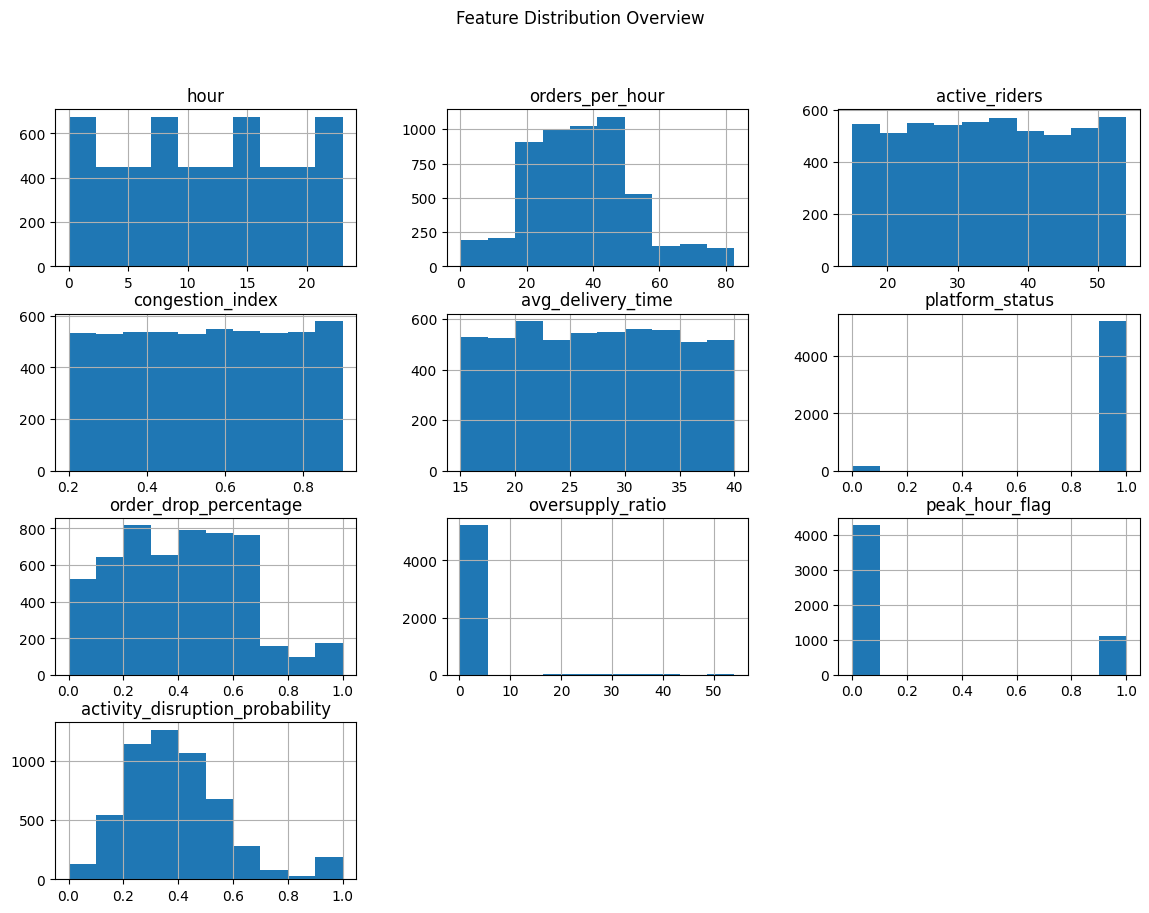

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("activity_model_dataset.csv")   # change file name

print(df.head())
print(df.describe())

df.hist(figsize=(14,10))
plt.suptitle("Feature Distribution Overview")
plt.show()

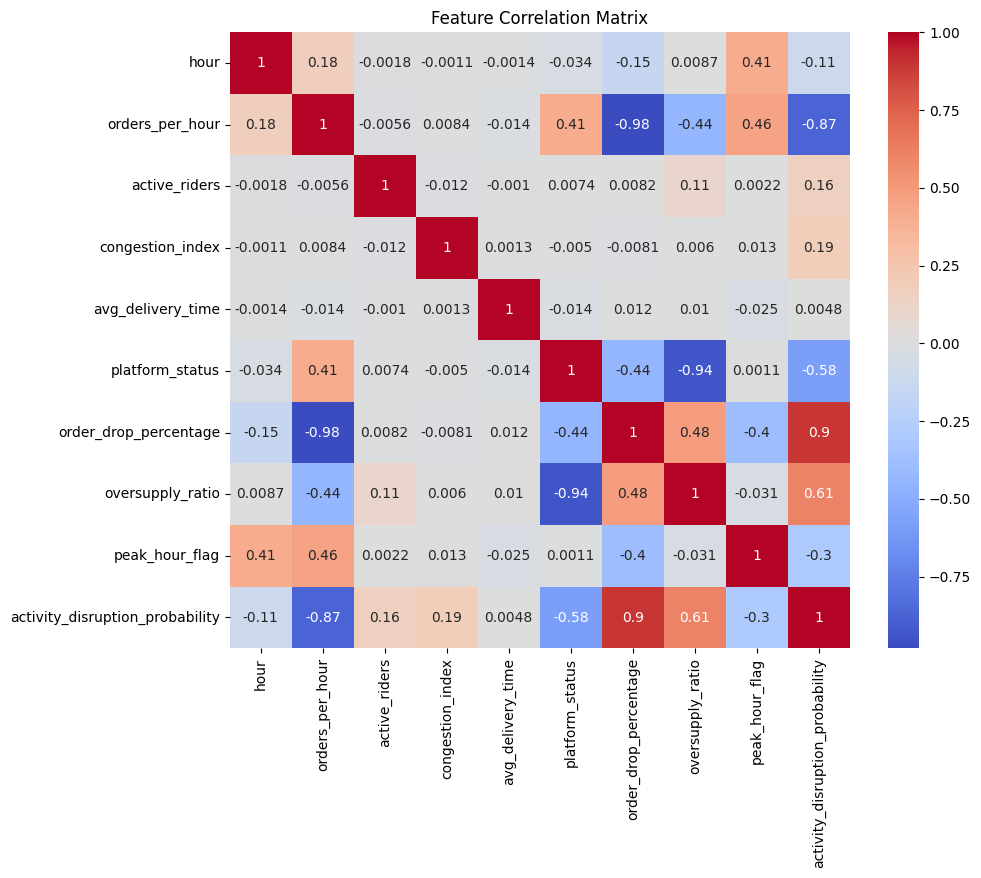

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

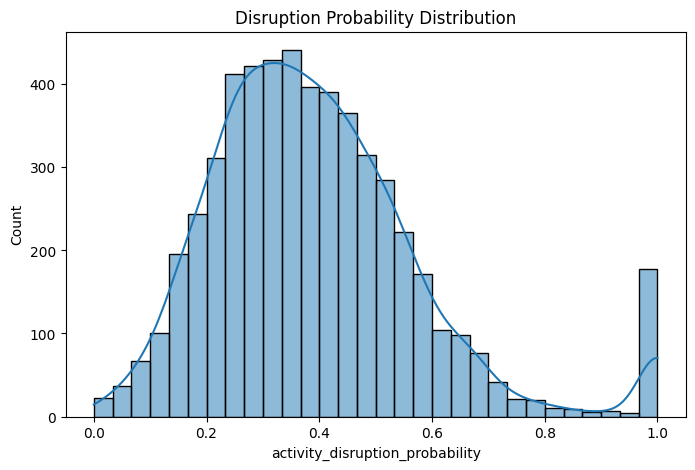

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["activity_disruption_probability"], bins=30, kde=True)
plt.title("Disruption Probability Distribution")
plt.show()

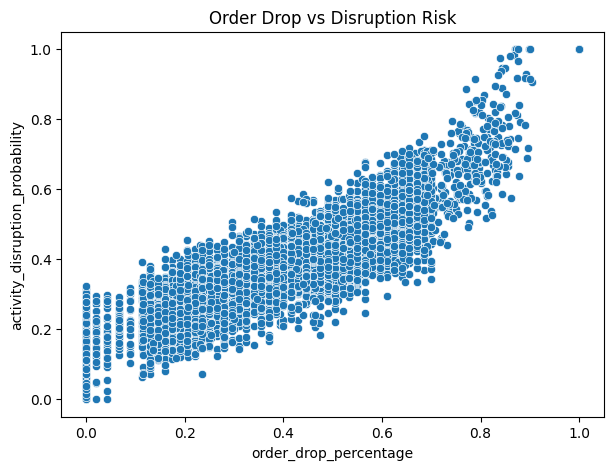

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["order_drop_percentage"],
    y=df["activity_disruption_probability"]
)
plt.title("Order Drop vs Disruption Risk")
plt.show()

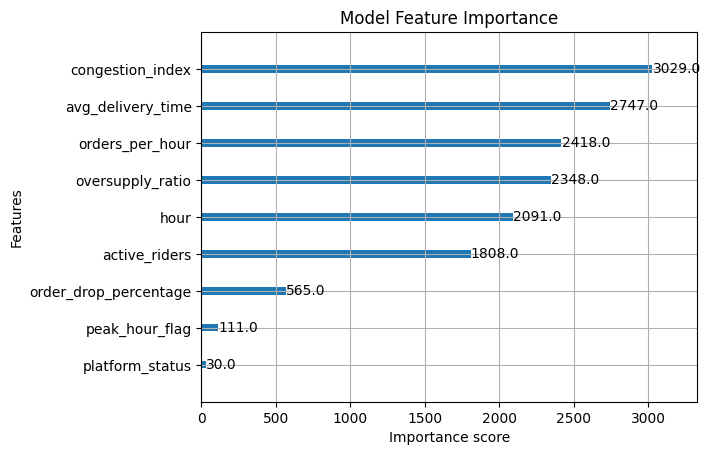

In [23]:
import joblib
import xgboost as xgb

model = joblib.load("activity_risk_model.pkl")

xgb.plot_importance(model, max_num_features=10)
plt.title("Model Feature Importance")
plt.show()

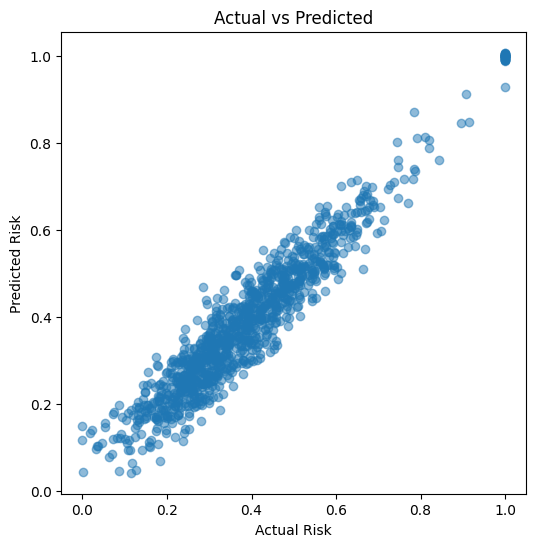

In [24]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "hour",
    "orders_per_hour",
    "active_riders",
    "congestion_index",
    "avg_delivery_time",
    "platform_status",
    "order_drop_percentage",
    "oversupply_ratio",
    "peak_hour_flag"
]

X = df[feature_cols]
y = df["activity_disruption_probability"]

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preds = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual Risk")
plt.ylabel("Predicted Risk")
plt.title("Actual vs Predicted")
plt.show()

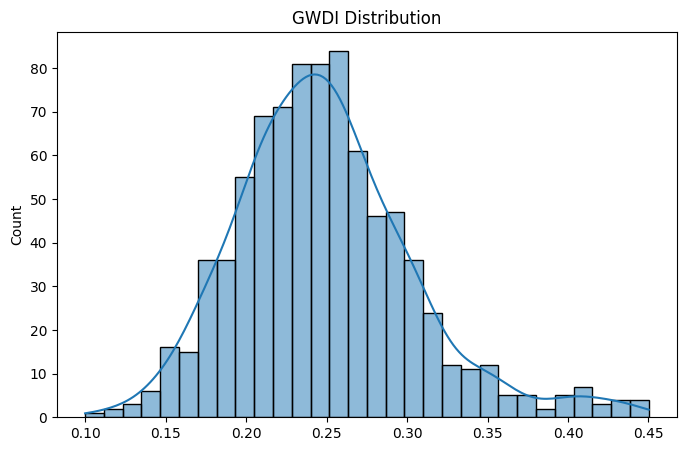

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rain = pd.read_csv("rain_model_dataset.csv")
heat = pd.read_csv("heat_model_dataset.csv")
poll = pd.read_csv("pollution_model_dataset.csv")
act = pd.read_csv("activity_model_dataset.csv")

# take minimum common length
n = min(len(rain), len(heat), len(poll), len(act))

df_combined = pd.DataFrame({
    "rain_prob": rain["rain_disruption_probability"].sample(n).values,
    "heat_prob": heat["heat_risk_probability"].sample(n).values,
    "pollution_prob": poll["pollution_risk_probability"].sample(n).values,
    "activity_prob": act["activity_disruption_probability"].sample(n).values
})

# compute GWDI
gwdi = (
    0.35 * df_combined["rain_prob"] +
    0.20 * df_combined["heat_prob"] +
    0.20 * df_combined["pollution_prob"] +
    0.25 * df_combined["activity_prob"]
)

plt.figure(figsize=(8,5))
sns.histplot(gwdi, bins=30, kde=True)
plt.title("GWDI Distribution")
plt.show()